In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle

In [2]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

In [3]:

odir = "ps_data"
with open(f"{odir}/snap40/mvir/ps-intensity-gal_logM10.pickle", "rb") as f:
    Pk_mean_gal10 = pickle.load(f)
    Pk_gal10 = pickle.load(f)
print("shotnoise", Pk_gal10.attrs["shotnoise"])

shotnoise 130.52360745197086


In [4]:

logM_name = ""
ps_type = "gal"
object2shuffle = "gal"
interp="tsc"
Pk_shuffled_list = []
names_list = []
seed_i = 0
seed_f = 100
n_seed = seed_f - seed_i

power_list = []
mean_intensities = []
odir = "ps_data"
snapnum=40

for seed in range(seed_i,seed_f):
    #fname = f"{odir}/snap40/mvir/2d/{slice_width}slice/shuffled_in_slice/logM10_zslice{islice}/seed{seed}.pickle"
    fname = f"{odir}/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/{ps_type}_ps/shuffle_{object2shuffle}/{logM_name}/seed{seed}.pickle"
    
   
    if seed == 0:
        print(fname)
    with open(fname, "rb") as f:
        Pk_mean_gal_shuffled = pickle.load(f)
        #print("mean", Pk_mean_cent_shuffled)
        Pk_gal_shuffled = pickle.load(f)
        #print(Pk_mean_gal_shuffled)
        power_list.append(Pk_gal_shuffled["power"].real)
        
        mean_intensities.append(Pk_mean_gal_shuffled)
        
        print("shotnoise", Pk_gal_shuffled.attrs["shotnoise"])
        Pk_shuffled_list.append(Pk_gal_shuffled)
        names_list.append(f"seed{seed}")
        

power_arr = np.array(power_list)

ps_data/snap40/mvir/shuffled/logM10_dlogM0.1/changed_bins/gal_ps/shuffle_gal//seed0.pickle
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197075
shotnoise 130.52360745197083
shotnoise 130.52360745197083
shotnoise 130.52360745197086
shotnoise 130.52360745197083
shotnoise 

is list
shotnoise:  130.52360745197083
shotnoise:  130.52360745197086
0


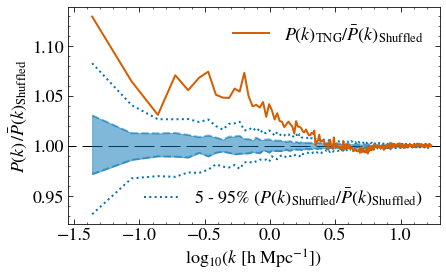

In [40]:
color_leg = ps.residual_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list], percentiles=[25, 5], labels=["Centrals", "Satellites" ], ratio_ylabel_list=["Shuffled",""], return_color_leg=True)

leg = plt.legend(handles=color_leg[1:], labels=[r"$P(k)_{\rmTNG}/\bar{P}(k)_{\rmShuffled}$"], loc='upper right', bbox_to_anchor=(1, 1))
ax = plt.gca()
ax.add_artist(leg)
dot_line = Line2D([],[],color=palette_tab10[0], linestyle="dotted")
plt.legend(handles=[dot_line], labels=[r"5 - 95% $(P(k)_{\rm Shuffled}/\bar{P}(k)_{\rm Shuffled})$"], loc='lower right', bbox_to_anchor=(1, 0))


#plt.savefig("figures/shuffled_ps_main.pdf", format="pdf", bbox_inches="tight")

is list
shotnoise:  130.52360745197083
shotnoise:  130.52360745197086


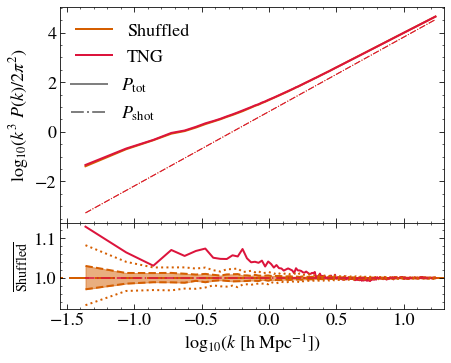

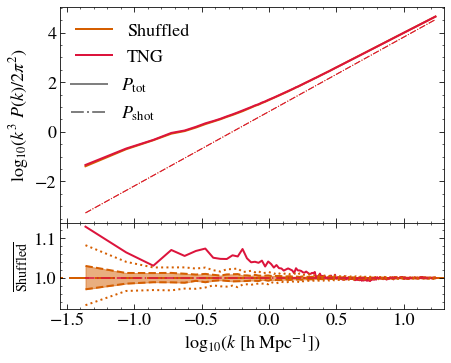

In [19]:
ps.compare_ps_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list], percentiles=[25, 5], labels=["Shuffled", "TNG" ], ratio_ylabel_list=["Shuffled",""])


#plt.savefig("figures/shuffled_ps_main.pdf", format="pdf", bbox_inches="tight")

is list
shotnoise:  130.52360745197083
shotnoise:  130.52360745197086


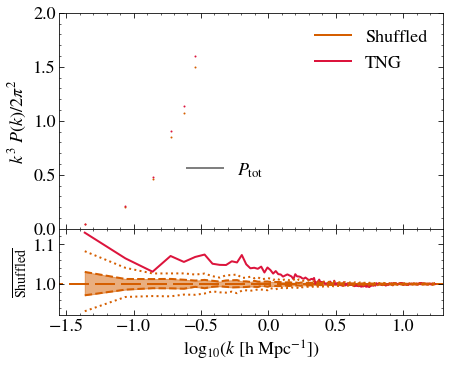

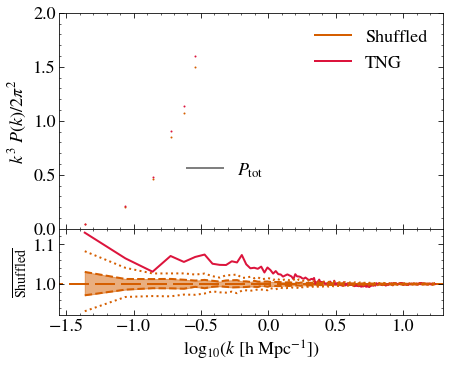

In [27]:
ps.compare_ps_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list], percentiles=[25, 5], labels=["Shuffled", "TNG" ], ratio_ylabel_list=["Shuffled",""], log=False, ylim1=[0,2], shotnoise_ps=False)


is list
shotnoise:  130.52360745197083
shotnoise:  130.52360745197086


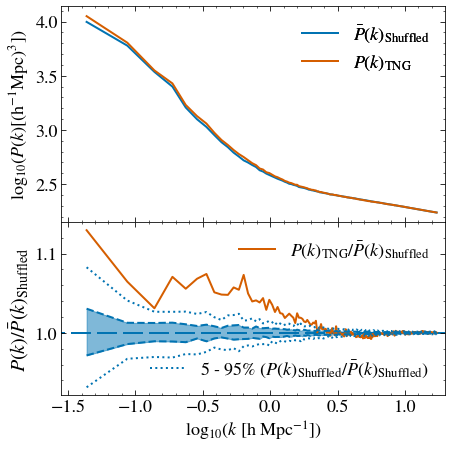

In [60]:
ps.compare_ps_plot([Pk_gal10], mean_of_seeds_lists=[Pk_shuffled_list], percentiles=[25, 5], ratio_ylabel=r"$P(k)/\bar{P}(k)_{\rmShuffled}$", labels=[r"$\bar{P}(k)_{\rmShuffled}$", r"$P(k)_{\rmTNG}$"], ratio_ylabel_list=[r"Shuffled",r"TNG"], log=True, var=False,  shotnoise_ps=False, color_list=[palette_tab10[0],palette_tab10[3]], grey_legend=False)
leg = plt.legend(handles=color_leg[1:], labels=[r"$P(k)_{\rmTNG}/\bar{P}(k)_{\rmShuffled}$"], loc='upper right', bbox_to_anchor=(1, 1))
ax = plt.gca()
ax.add_artist(leg)
dot_line = Line2D([],[],color=palette_tab10[0], linestyle="dotted")
plt.legend(handles=[dot_line], labels=[r"5 - 95% $(P(k)_{\rm Shuffled}/\bar{P}(k)_{\rm Shuffled})$"], loc='lower right', bbox_to_anchor=(1, 0))

#plt.savefig("figures/shuffled_ps_main_w_absolute.pdf", format="pdf", bbox_inches="tight")